# This file or LDA will not be used but left it here if you want to see 

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from gensim import models, corpora 
from itertools import combinations
import pyLDAvis
import pyLDAvis.gensim_models 
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import umap
import hdbscan
import plotly.express as px 

import spacy 
import string
import random
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
# from pyod.models.xgbod import XGBOD
# from sentence_transformers import SentenceTransformer
# conda install pyod 
# conda install xgboost

/ocean/projects/cis240109p/mmarius/env/PNC2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-25 23:35:36.962411: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-25 23:35:39.908836: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-25 23:35:41.301104: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745638541.977375 3798552 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745638542.136102 3798552 cud

# Function to remove stop words (one with lemmatization and other without )

In [3]:
# to remove stop words 
nlp = spacy.load("en_core_web_sm")
stop_words = nlp.Defaults.stop_words
stop_words= list(stop_words) + ['card','I']
def remove_stopwords(text):
    
    # Convert to lowercase converts to tokens so easy to get lemmatize 
    doc = nlp(text.lower())
    cleaned_words = [
    token.lemma_  # Lemmatization
    for token in doc
    if token.lemma_ not in string.punctuation and token.lemma_ not in stop_words
    
]

    return " ".join(cleaned_words)


def remove_stopwords_woLemma(text):# same but not lemmatilization
    
    # Convert to lowercase converts to tokens so easy to get lemmatize 
    doc = nlp(text.lower())
    cleaned_words = [
    token.text  # Lemmatization
    for token in doc
    if token.text not in string.punctuation and token.text not in stop_words
    
]

    return " ".join(cleaned_words)

# Creating mult models and choosing best based on coherence score 

In [4]:
# Hyperparameter Tuning for Optimal Topics
def find_optimal_topics(corpus,dictionary,texts,min_topics=5, max_topics=25, step=5):
    coherence_values = []
    all_models = []
    
    for num_topics in range(min_topics, max_topics+1, step):
        model = models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            alpha='auto',
            eta='auto',
            passes=15
        )
        
        coherence = models.CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        ).get_coherence()
        
        coherence_values.append(coherence)
        all_models.append(model)
        print(f"Topics: {num_topics} | Coherence: {coherence:.3f}")
    
    optimal_index = np.argmax(coherence_values)
    return all_models[optimal_index], coherence_values[optimal_index]





# Computes LDA model stability via Jaccard 

In [5]:
# Stability Analysis with Jaccard Similarity
def jaccard_similarity(topic1, topic2):
    """Calculate Jaccard similarity between two topics"""
    set1 = set([word for word, _ in topic1])
    set2 = set([word for word, _ in topic2])
    return len(set1 & set2) / len(set1 | set2)

def stability_analysis(lda_model,corpus,dictionary,num_runs=5):
    all_topics = []
    for _ in range(num_runs):
        model = models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=lda_model.num_topics,
            alpha='auto',  # Automatic asymmetric alpha
            eta='auto',    # Automatic asymmetric eta
            passes=15,
        )
        
        all_topics.append([model.show_topic(tid, topn=10) for tid in range(model.num_topics)]) #getting words and weights that contribute to topic
    
    # Compare topic words across runs
    similarities = []
    for run1, run2 in combinations(all_topics, 2):
        run_sim = [max(jaccard_similarity(t1, t2) for t2 in run2) for t1 in run1]
        similarities.append(np.mean(run_sim))
    
    return np.mean(similarities) # getting average jaccard similarity per run


In [6]:
train=pd.read_csv('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/task-specific-datasets/banking_data/train.csv')
test=pd.read_csv('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/task-specific-datasets/banking_data/test.csv')
data=pd.concat([train,test]).reset_index()
data=data.drop(columns=['index'])

In [7]:
data.describe()

,text,category
count,13083,13083
unique,13083,77
top,I am still waiting on my card?,card_payment_fee_charged
freq,1,227


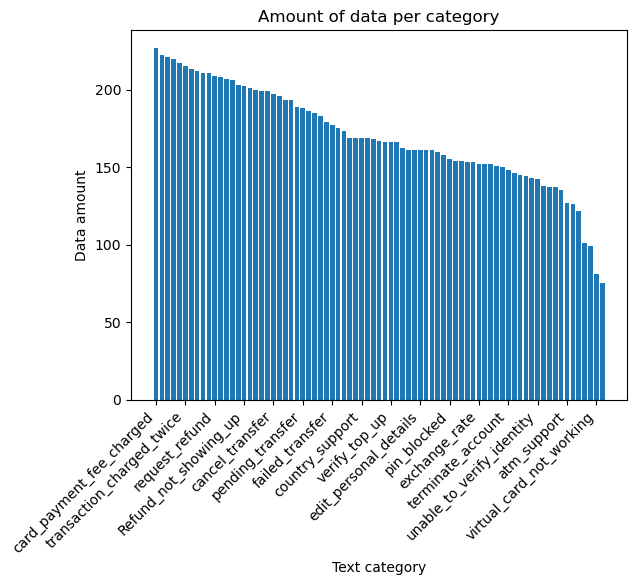

In [8]:

plt.bar(data['category'].value_counts().index ,data['category'].value_counts());
plt.xticks(data['category'].value_counts().index[::5]);
plt.xticks(rotation=45, ha='right');
plt.xlabel('Text category');
plt.ylabel('Data amount');
plt.title('Amount of data per category');


Text(0.5, 1.0, 'char count')

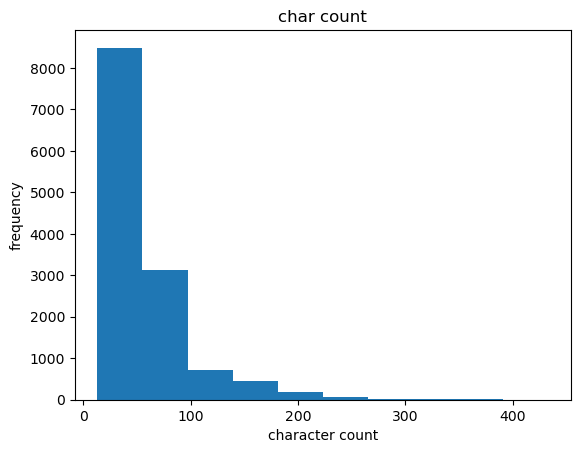

In [9]:
data['char_count'] = data['text'].str.len()
data['word_count'] = data['text'].str.split().str.len()
plt.hist(data['char_count']);
plt.xlabel('character count');
plt.ylabel('frequency');
plt.title('char count')

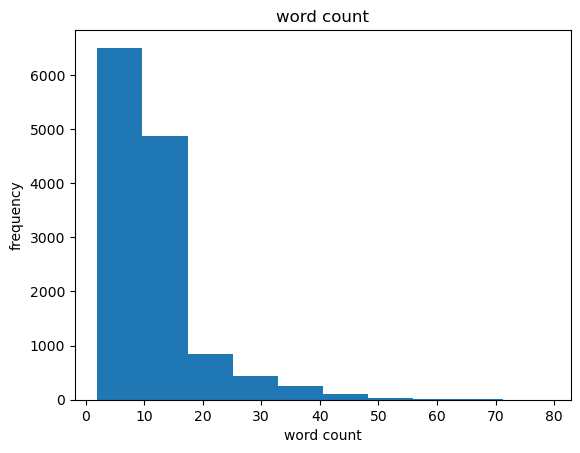

In [10]:
plt.hist(data['word_count']);
plt.xlabel('word count');
plt.ylabel('frequency');
plt.title('word count');

# Performing LDA model to find overall topics in text 

will later use this to define anomalies / non anomaly text 

In [11]:
# Creating bag of word from data
texts = [document.lower().split() for document in data['text'].apply(remove_stopwords)]
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]


got 45 topics from 'topic_creation.py' file and also chart. On average the highest coherence score was between 45 and 50 topics so choose 45

In [12]:

best_model = models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=45,
            alpha='auto',
            eta='auto',
            passes=15
        )

# Coherence 
( do an auc cuve fortopics and cohernce score to see platue
I'm using Coherence score to find the optimal number of topics based on word similarity per topic.
The lower the cohernece score the worse the topic/word realtionship is but the higher the coherence score, the better the words relate per topic.

Tells how good or human interpertable the topics are semantically
good breakdown link 
https://stackoverflow.com/questions/54762690/evaluation-of-topic-modeling-how-to-understand-a-coherence-value-c-v-of-0-4


# Stability
Im performing Jaccard similarity test becuase I want to see how often I'll get the same topics for each run espically since i get new topics every run.

See's how consistent or close each topic overlaps (what i'm doing )

ranges from 0-1 higher scores means more similarity compared to lower scores 


# Perplixity 
(over all lower score the better)
Measures the models ability to predict unseen documents to a topic 

# Chart analysis explanaition 

Right Side 

- Red Bars: Show term frequency within the selected topic

- Blue Bars: Show overall term frequency across all documents

- High λ: Shows common terms that strongly represent the topic

- Low λ: Reveals distinctive terms that uniquely identify the topic

Comparing bars:

- Large gap between red and blue: Term is distinctive to this topic

- Similar heights: Term appears similarly across multiple topics

Left Side 

- smaller circles means less data assigned to topic
- bigger circles means more data affiliated with topic 
- overlapping or close means similar in topic 



https://developer.ibm.com/tutorials/awb-lda-topic-modeling-text-analysis-python/#step-9-text-classification11

In [13]:

pyLDAvis.display.DEFAULT_DIV_STYLE = "background-color:white; width:100%; height:100%;"

best_visual = pyLDAvis.gensim_models.prepare(best_model, corpus, dictionary, mds='mmds')
pyLDAvis.display(best_visual)

In [14]:
print(f"Model coherence (with lemmea): {coherence_score:.2f}" )
stability_score = stability_analysis(best_model,num_runs=10)
print(f"Average topic stability across runs(with lemmea): {stability_score:.2f}")

print(f"Model perplexity (with lemmea): {best_model.log_perplexity(corpus):.2f}" )

NameError: name 'coherence_score' is not defined

In [ ]:

# Get 
doc_topics = [] # will contain all labels for each dataset
for doc in corpus:
    # Get topic probabilities for document
    topic_probs = best_model.get_document_topics(doc)
    # returns ( label and probability )
    dominant_topic = max(topic_probs, key=lambda x: x[1]) # returns ( label and probability )
    # later use to make labels if topic is good 
    doc_topics.append(dominant_topic[0])

NameError: name 'corpus' is not defined

making visual

In [21]:
data_ts_3 = np.load('/ocean/projects/cis240109p/mmarius/PNC_work/NLP/TSNE_3.npy')
TSNE = pd.DataFrame(data_ts_3, columns= ['PC1','PC2','PC3'])
TSNE['labels']=doc_topics
TSNE['text']=data['text']

In [23]:
# looping and sorting based on labels
labels_frequency=[]
for label in np.unique(doc_topics):
    frequency=[]
    # removing stopword and not lemmatizng so to 5 words are useful
    texts = [document.lower().split() for document in TSNE['text'][TSNE['labels']==label].apply(remove_stopwords_woLemma)]
    dictionary = corpora.Dictionary(texts)
    # sorting
    sorted_words = sorted(dictionary.dfs.items(), key=lambda x: x[1], reverse=True)
    for id, freq in sorted_words[:5]:  # Top 5 most frequent
        frequency.append(f'{dictionary[id]}:{freq}')
        # adding to final list that'll have all top 5 words frequencies for each labels 
    labels_frequency.append(frequency)

TSNE['freq']=TSNE['labels'].apply(lambda x: labels_frequency[x] )

In [25]:
fig = px.scatter_3d(TSNE, x='PC1', y='PC2', z='PC3',color='labels',hover_data=['text','freq'], opacity=0.7)
fig.update_traces(marker=dict(size=3))
fig.update_layout(title="3D PCA Plot of Topics-TSNE")
fig.write_html("Topics-TSNE.html")

# Testing best model without lemmetization

In [5]:
# Creating bag of word from data
texts = [document.lower().split() for document in data['text'].apply(remove_stopwords_woLemma)]
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]


In [ ]:
model = models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=45,
            alpha='auto',
            eta='auto',
            passes=15
        )

In [9]:
# pyLDAvis.enable_notebook()
best_visual = pyLDAvis.gensim_models.prepare(model, corpus, dictionary, mds='mmds')
pyLDAvis.display(best_visual)

(without lemma 45 topics)
hard to understand topics also 

In [11]:
coherence = models.CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        ).get_coherence()
print(f"Model coherence (with lemmea): {coherence:.2f}" )


print(f"Model perplexity (with lemmea): {model.log_perplexity(corpus):.2f}" )

Model coherence (with lemmea): 0.58
Model perplexity (with lemmea): -13.68


# Creating LDA Model by baised on requirments

1. word has to appear more than 2 times to be considered
2. removing words that appear in over 90 percent of the documents(or can manually remove words by adding to stop words)
3. Also not adding lemmatization since our text is short

In [5]:
# Creating bag of word from data
texts = [document.lower().split() for document in data['text'].apply(remove_stopwords_woLemma)]
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below = 4, no_above= .9) # must appear 4 times in text and not be in 90% of the comments 
corpus = [dictionary.doc2bow(text) for text in texts]

In [6]:
model2 = models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=45,
            alpha='auto',
            eta='auto',
            passes=15
        )

In [7]:
# pyLDAvis.enable_notebook()
best_visual = pyLDAvis.gensim_models.prepare(model2, corpus, dictionary, mds='mmds')
pyLDAvis.display(best_visual)

In [16]:
coherence = models.CoherenceModel(
            model=model2,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        ).get_coherence()
print(f"Model coherence (with lemmea): {coherence:.2f}" )
# stability_score = stability_analysis(model2,num_runs=10)
# print(f"Average topic stability across runs(with lemmea): {stability_score:.2f}")

print(f"Model perplexity (with lemmea): {model2.log_perplexity(corpus):.2f}" )

Model coherence (with lemmea): 0.64
Model perplexity (with lemmea): -12.15


#### notes ######
Based on lda model u choose, maybe look at the topics with the least amount of data points assigned to it( possibily might be anomalas)

Asked on how to actaully analyze becaue alot of topics dont make sense 

